# EDA — the Nepanglish corpus: who speaks, how much they mix, and where recognition breaks

Four questions, in this order:

1. **Who is speaking, and for how long?** Voice prints (ECAPA speaker embeddings) turn 42
   episodes into a list of distinct people with their talk time. That is also what gives
   gender and age *per second of speech* rather than per episode.
2. **What does the corpus hold?** Hours by genre, gender, age; how much the speech mixes
   languages (CMI); how fast people talk.
3. **How do the three recognisers do as mixing increases?** WER and CER at low, medium and
   heavy code-mixing.
4. **How do they do as speech gets faster?**

**Read before quoting a number.** Every reference started as the fused transcript of the same
three recognisers (D74), and only 3 of 1,170 verified labels were edited; 82% of rows were
screened and never played. So a WER here is a recogniser's distance from a lightly checked fusion
of all three, not from an independent transcription. Differences *between strata* are more
trustworthy than any absolute level.

Run with `make notebook-run` (or `make notebook`). The first run embeds 22 h of audio on the CPU
(~20 min on 16 threads); embeddings are cached in `notebooks/.cache-diar/`.

In [1]:
import os

os.environ.setdefault("OMP_NUM_THREADS", str(os.cpu_count()))

import json
import re
import sys
import time
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torchaudio
from joblib import Parallel, delayed
from rapidfuzz.distance import Levenshtein
from scipy.stats import spearmanr
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
torch.set_num_threads(os.cpu_count())
torch.set_grad_enabled(False)

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "backend"))
from app.services.fold import fold_tokens, fold_version, word_errors  # noqa: E402

ANALYTICS = REPO / "exports" / "analytics" / "analytics.jsonl"
EPISODES = REPO / "data" / "objects" / "episodes"
FIGURES = REPO / "notebooks" / "figures"
CACHE = REPO / "notebooks" / ".cache-diar"
MODELS = REPO / "data" / "models"
FIGURES.mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)
# The backend container creates data/models as root when it fetches the aligner (D42).
if not os.access(MODELS, os.W_OK):
    MODELS = CACHE / "models"

SYSTEMS = ["elevenlabs-scribe-v2", "gemini-3.8-flash", "mai-transcribe-2"]
SHORT = {"elevenlabs-scribe-v2": "Scribe", "gemini-3.8-flash": "Gemini", "mai-transcribe-2": "MAI"}
# The first three slots of the reference categorical palette: the only three that stay
# distinguishable for every colour-vision type when all pairs are on screen at once.
SYS_COLOR = dict(zip(SYSTEMS, ["#2a78d6", "#eb6834", "#1baf7a"]))
TIERS = ["Low (<10)", "Medium (10-30)", "Heavy (>=30)", "English only"]
TIER_COLOR = dict(zip(TIERS, ["#9cc3ee", "#4d8fdc", "#1d5aa6", "#8f8d86"]))  # one hue, light->dark
GENDER_COLOR = {"female": "#2a78d6", "male": "#eb6834", "unresolved": "#b9b7b0"}
INK, MUTED = "#0b0b0b", "#52514e"

plt.style.use("default")
plt.rcParams.update({
    "font.size": 9.5, "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.edgecolor": "#c9c8c2", "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": "#ecebe7", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "legend.frameon": False,
})
# Episode ids and titles mix scripts. matplotlib falls back per glyph only through a family list,
# so Devanagari labels get DejaVu Sans (ships with matplotlib) with a Devanagari face behind it.
_installed = {f.name for f in plt.matplotlib.font_manager.fontManager.ttflist}
DEVA_FONT = next((n for n in ("Noto Sans Devanagari", "Noto Serif Devanagari", "FreeSans")
                  if n in _installed), None)


def script_aware(texts):
    """Give labels that contain Devanagari a font list that can draw both scripts."""
    for text in texts:
        if DEVA_FONT and re.search(r"[ऀ-ॿ]", text.get_text()):
            text.set_fontfamily(["DejaVu Sans", DEVA_FONT])
    return texts


def save(fig, name):
    fig.savefig(FIGURES / f"eda_{name}.png", dpi=150, bbox_inches="tight")


pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

rows, hyps, EP_META = [], {}, {}
with ANALYTICS.open(encoding="utf-8") as fh:
    for line in fh:
        r = json.loads(line)
        by_sys = {h["system_id"]: h for h in r["hypotheses"]}
        scribe_words = (by_sys.get("elevenlabs-scribe-v2") or {}).get("words") or []
        spans = [(w["start"], w["end"]) for w in scribe_words if w["start"] is not None]
        rows.append({
            "segment_id": r["segment_id"], "episode": r["episode_id"], "pot": r["pot"],
            "tier_label": r["verification_tier"], "disposition": r["disposition"],
            "start": r["start_time"], "end": r["end_time"], "duration": r["duration_seconds"],
            # Speech span from Scribe's own word timings: the clip minus its leading and trailing
            # silence, which is the right denominator for a speaking rate.
            "span": (spans[-1][1] - spans[0][0]) if spans else np.nan,
            "genre": (r["episode_metadata"] or {}).get("genre"),
            # Seconds of crosstalk in the clip (D77): NaN when the export never measured it, 0 when
            # it did and found none -- the two are kept apart all the way through.
            "overlap_s": (sum(b - a for a, b in r["overlap_spans"])
                          if r.get("overlap_spans") is not None else np.nan),
            "text": r["text"] or "",
        })
        hyps[r["segment_id"]] = {s: (by_sys.get(s) or {}).get("text") or "" for s in SYSTEMS}
        EP_META.setdefault(r["episode_id"], r["episode_metadata"] or {})

seg = pd.DataFrame(rows).set_index("segment_id")
print(f"{len(seg):,} labeled clips, {seg.duration.sum() / 3600:.2f} h, {seg.episode.nunique()} episodes "
      f"| fold {fold_version()}")
print(f"verification: {seg.tier_label.value_counts().to_dict()}  |  "
      f"edited: {int((seg.disposition == 'edited').sum())}")

7,581 labeled clips, 26.69 h, 126 episodes | fold fold-v3+norm-v3
verification: {'screened': 5875, 'verified': 1706}  |  edited: 26


## Scoring every clip

Three numbers per clip and recogniser, each summed over clips as errors / reference units (never
a mean of per-clip rates, which would let a 3-word clip count as much as a 60-word one):

- **WER** — script-folded, through `app/services/fold.py`: `टिम` and `team` are the same word,
  `गर्नुभयो`/`गर्नु भयो` is one. This is the harness's WER and the headline everywhere below.
- **raw WER** — plain token match. The gap to WER is how much a recogniser loses to *spelling*.
- **CER** — character edit distance on the raw tokens. It cannot see across scripts, so a
  recogniser that writes English in Devanagari pays for it here in full.

Also per clip: **CMI** from the reference (Devanagari vs Latin tokens; numbers are neutral) and
**speaking rate** in words per second of speech.

In [2]:
DEV = re.compile(r"[ऀ-ॿ]")
LAT = re.compile(r"[A-Za-z]")


def chars(text):
    """The words fold.py compares, Latin lowercased, joined by single spaces: what CER is over."""
    return " ".join(t if DEV.search(t) else t.lower() for t in fold_tokens(text))


def score(ids, refs, hyp_rows):
    out = []
    for sid, ref, hy in zip(ids, refs, hyp_rows):
        toks = fold_tokens(ref)
        n_dev = sum(bool(DEV.search(t)) for t in toks)
        n_lat = sum(bool(LAT.search(t)) and not DEV.search(t) for t in toks)
        rec = {"segment_id": sid, "words": len(toks), "n_dev": n_dev, "n_lat": n_lat,
               "ref_chars": len(chars(ref))}
        for s in SYSTEMS:
            rec[f"{s}|werr"] = word_errors(ref, hy[s]).errors
            raw = word_errors(ref, hy[s], folded=False)
            rec[f"{s}|rerr"], rec[f"{s}|rwords"] = raw.errors, raw.ref_words
            rec[f"{s}|cerr"] = Levenshtein.distance(chars(ref), chars(hy[s]))
        out.append(rec)
    return out


t0 = time.time()
ids = seg.index.tolist()
chunks = np.array_split(np.arange(len(ids)), os.cpu_count() * 4)
parts = Parallel(n_jobs=-1)(
    delayed(score)([ids[i] for i in c], [seg.text.iat[i] for i in c], [hyps[ids[i]] for i in c])
    for c in chunks
)
metrics = pd.DataFrame([r for p in parts for r in p]).set_index("segment_id")
seg = seg.join(metrics)
print(f"scored {len(seg):,} clips x {len(SYSTEMS)} recognisers in {time.time() - t0:.1f}s")

n_mixed = seg.n_dev + seg.n_lat
seg["cmi"] = np.where(n_mixed > 0, 100 * (n_mixed - np.maximum(seg.n_dev, seg.n_lat)) / n_mixed.clip(lower=1), 0.0)
seg["latin_share"] = np.where(n_mixed > 0, seg.n_lat / n_mixed.clip(lower=1), np.nan)
seg["cmi_tier"] = np.select(
    [(seg.n_dev == 0) & (seg.n_lat > 0), seg.cmi < 10, seg.cmi < 30], [TIERS[3], TIERS[0], TIERS[1]],
    default=TIERS[2],
)
rate_den = seg.span.where(seg.span >= 1.0, seg.duration)
seg["rate"] = seg.words / rate_den
scored = seg[seg.words > 0].copy()
print(f"{len(seg) - len(scored)} clips have an empty reference and are left out of every rate")


def wer_table(frame, cluster=None, n_boot=2000, seed=0):
    """Corpus-level WER / raw WER / CER per recogniser, with a clustered 95% CI on WER."""
    out = {}
    for s in SYSTEMS:
        row = {
            "WER %": 100 * frame[f"{s}|werr"].sum() / frame.words.sum(),
            "raw WER %": 100 * frame[f"{s}|rerr"].sum() / frame[f"{s}|rwords"].sum(),
            "CER %": 100 * frame[f"{s}|cerr"].sum() / frame.ref_chars.sum(),
        }
        if cluster is not None:
            g = frame.groupby(cluster).agg(e=(f"{s}|werr", "sum"), w=("words", "sum"))
            rng = np.random.default_rng(seed)
            pick = rng.integers(0, len(g), size=(n_boot, len(g)))
            boot = 100 * g.e.to_numpy()[pick].sum(1) / g.w.to_numpy()[pick].sum(1)
            row["WER lo"], row["WER hi"] = np.percentile(boot, [2.5, 97.5])
        out[SHORT[s]] = row
    return pd.DataFrame(out).T


display(wer_table(scored))

scored 7,581 clips x 3 recognisers in 37.8s
26 clips have an empty reference and are left out of every rate


,WER %,raw WER %,CER %
Scribe,10.12,19.01,9.76
Gemini,9.27,20.27,10.48
MAI,10.15,19.32,10.66


## 1. Who is speaking, and for how long?

**Method.** Every labeled clip is cut into 3-second windows on a 1.5-second hop and embedded with
`speechbrain/spkrec-ecapa-voxceleb` (ungated, 192-d, trained on VoxCeleb). Then:

1. **Within each episode**, the windows are split into as many voices as the episode's metadata
   declares (k-means on the unit sphere). Using the declared count is the standard "oracle number
   of speakers" condition; a threshold alone could not separate the same-gender podcast pairs
   that make up most of this corpus.
2. **Across the corpus**, every pair of voices is compared by centroid cosine similarity. The
   link threshold is read off the data: the largest gap in the sorted cross-episode similarities.
   Voices above it are the same person — including two voices split out of one episode, so a
   split the metadata forced on a single speaker merges back.
3. **Each clip** gets the speaker that holds the majority of its windows; talk time is the sum of
   those clips' durations. Clips under 1.5 s have no window and stay unassigned.

**What it cannot do.** A cosine threshold is not an identity, and ECAPA was trained on English
celebrity interviews, not Nepali podcasts. The checks after the clustering are what earn trust:
known series hosts must recur, a declared male reviewer must not join the female reviewers, and
the count should match what the metadata implies. Nobody who speaks for under 30 seconds exists
here, by construction.

In [3]:
SR, WIN, HOP, MIN_WIN = 16_000, 48_000, 24_000, 24_000
HOP_S = HOP / SR
segments = defaultdict(list)
for sid, r in seg.iterrows():
    segments[r.episode].append((r.start, r.end, sid))
EPS = sorted(segments)
N_SAMPLES = {}
for ep in EPS:
    info = sf.info(str(EPISODES / ep / "audio.flac"))
    assert info.samplerate == SR and info.channels == 1, f"{ep}: expected 16 kHz mono"
    N_SAMPLES[ep] = info.frames


def window_plan(ep):
    """(start sample, samples of real audio, source clip) for every window of one episode."""
    offs, nsamp, src = [], [], []
    for start, end, sid in sorted(segments[ep]):
        a, b = int(start * SR), min(int(end * SR), N_SAMPLES[ep])
        for off in range(a, max(a + 1, b - MIN_WIN + 1), HOP):
            n = min(off + WIN, b) - off
            if n < MIN_WIN:
                break
            offs.append(off)
            nsamp.append(n)
            src.append(sid)
    return np.asarray(offs, dtype=np.int64), np.asarray(nsamp, dtype=np.int64), src


PLAN = {ep: window_plan(ep) for ep in EPS}
CACHE_KEY = "ecapa_w3.0_h1.5_m1.5"  # same key as the old 02-diarization notebook, so its cache is reused
encoder = None


def embed(ep):
    """L2-normalised ECAPA embeddings for one episode's windows, cut a batch at a time."""
    global encoder
    path = CACHE / f"{CACHE_KEY}__{ep}.npy"
    if path.exists():
        return np.load(path)
    if encoder is None:
        from speechbrain.inference.speaker import EncoderClassifier
        encoder = EncoderClassifier.from_hparams(
            source="speechbrain/spkrec-ecapa-voxceleb",
            savedir=str(MODELS / "spkrec-ecapa-voxceleb"), run_opts={"device": "cpu"})
    audio, _ = sf.read(EPISODES / ep / "audio.flac", dtype="float32")
    offs, nsamp, _ = PLAN[ep]
    out = []
    for i in range(0, len(offs), 64):
        o, n = offs[i:i + 64], nsamp[i:i + 64]
        buf = np.zeros((len(o), WIN), dtype=np.float32)
        for k, (off, m) in enumerate(zip(o, n)):
            buf[k, :m] = audio[off:off + m]
        rel = torch.from_numpy((n / WIN).astype(np.float32))  # padding is declared, not pooled
        out.append(encoder.encode_batch(torch.from_numpy(buf), wav_lens=rel).squeeze(1).numpy())
    emb = np.concatenate(out).astype(np.float32)
    emb /= np.linalg.norm(emb, axis=1, keepdims=True)
    np.save(path, emb)
    return emb


def pitch_sample(ep, n=300, seed=0):
    """Median F0 (Hz) of up to n random windows per episode: a weak, cheap cue, cached."""
    path = CACHE / f"f0_{CACHE_KEY}__{ep}.npz"
    if path.exists():
        z = np.load(path)
        return z["idx"], z["f0"]
    audio, _ = sf.read(EPISODES / ep / "audio.flac", dtype="float32")
    offs, nsamp, _ = PLAN[ep]
    idx = np.sort(np.random.default_rng(seed).choice(len(offs), min(n, len(offs)), replace=False))
    f0 = []
    for i in idx:
        track = torchaudio.functional.detect_pitch_frequency(
            torch.from_numpy(audio[offs[i]:offs[i] + nsamp[i]].copy()), SR, freq_low=60, freq_high=400).numpy()
        track = track[(track > 60) & (track < 400)]
        f0.append(np.median(track) if len(track) else np.nan)
    np.savez(path, idx=idx, f0=np.asarray(f0))
    return idx, np.asarray(f0)


t0 = time.time()
E = {ep: embed(ep) for ep in EPS}
F0 = {ep: pitch_sample(ep) for ep in EPS}
window_hours = sum(int(p[1].sum()) for p in PLAN.values()) / SR / 3600
print(f"{sum(len(v) for v in E.values()):,} windows ({window_hours:.1f} h of window audio) embedded "
      f"in {time.time() - t0:.0f}s" + ("  (from cache)" if time.time() - t0 < 60 else ""))

60,391 windows (48.7 h of window audio) embedded in 334s


In [4]:
MIN_VOICE_WINDOWS = int(30 / HOP_S)   # 30 s of speech to count as a voice
MIN_LINK_WINDOWS = int(60 / HOP_S)    # 60 s to be trusted as a centroid for linking

voices = []
for ep in EPS:
    k = len(EP_META[ep].get("speakers") or {}) or 1
    labels = np.zeros(len(E[ep]), int) if k == 1 else \
        KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(E[ep])
    f_idx, f_val = F0[ep]
    for c in range(k):
        member = labels == c
        if member.sum() < MIN_VOICE_WINDOWS:
            continue
        cen = E[ep][member].mean(0)
        voices.append({"episode": ep, "cluster": c, "windows": int(member.sum()),
                       "pitch": float(np.nanmedian(f_val[member[f_idx]])) if member[f_idx].any() else np.nan,
                       "centroid": cen / np.linalg.norm(cen), "labels": labels})
V = pd.DataFrame(voices)
C = np.stack(V.centroid.to_numpy())
S = C @ C.T
L = V.index[V.windows >= MIN_LINK_WINDOWS].to_numpy()

cross = np.sort([S[i, j] for a, i in enumerate(L) for j in L[a + 1:] if V.episode[i] != V.episode[j]])
g = int(np.argmax(np.diff(cross)))
GAP_LO, GAP_HI = float(cross[g]), float(cross[g + 1])
LINK = (GAP_LO + GAP_HI) / 2

parent = list(range(len(V)))


def root(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x


for a, i in enumerate(L):
    for j in L[a + 1:]:
        if S[i, j] >= LINK:
            parent[root(i)] = root(j)
roots = {r: f"S{n:02d}" for n, r in enumerate(dict.fromkeys(root(i) for i in L))}
V["speaker"] = [roots.get(root(i)) if i in set(L) else None for i in V.index]

# Each clip goes to the voice holding most of its windows.
clip_voice = {}
for ep in EPS:
    ep_voices = V[V.episode == ep]
    if ep_voices.empty:
        continue
    labels = ep_voices.labels.iloc[0]
    to_voice = {c: vi for vi, c in zip(ep_voices.index, ep_voices.cluster)}
    votes = defaultdict(Counter)
    for lab, sid in zip(labels, PLAN[ep][2]):
        if lab in to_voice:
            votes[sid][to_voice[lab]] += 1
    for sid, cnt in votes.items():
        clip_voice[sid] = cnt.most_common(1)[0][0]
seg["voice"] = pd.Series(clip_voice)
seg["speaker"] = seg.voice.map(V.speaker)
scored = seg[seg.words > 0].copy()

print(f"{len(V)} voices in {len(EPS)} episodes; {len(L)} with >=60 s are linked")
print(f"link threshold {LINK:.3f}, read off the widest gap in {len(cross):,} cross-episode similarities "
      f"({GAP_LO:.3f} -> {GAP_HI:.3f}, width {GAP_HI - GAP_LO:.3f})")
print(f"{seg.speaker.notna().mean():.1%} of clips ({seg.duration[seg.speaker.notna()].sum() / seg.duration.sum():.1%} "
      "of labeled time) are assigned a speaker")

135 voices in 126 episodes; 113 with >=60 s are linked
link threshold -0.110, read off the widest gap in 6,295 cross-episode similarities (-0.133 -> -0.087, width 0.046)
98.8% of clips (98.6% of labeled time) are assigned a speaker


**Checks.** If the titles and metadata are right, the corpus holds a known number of people: one
tech reviewer across 25 episodes, one host per series (Sanjay, the `ep_NNN` show, Bravo Delta) and
a different guest in every episode. The embeddings never saw that expectation.

In [5]:
def series(ep):
    if EP_META[ep].get("genre") == "tech_review":
        return "tech_review"
    for prefix in ("on_air_with_sanjay_", "the_bravo_delta_show_"):
        if ep.startswith(prefix):
            return prefix.strip("_")
    return "ep_podcast" if re.match(r"ep_\d+_", ep) else None


SERIES = {ep: series(ep) for ep in EPS}
slots = sum(len(EP_META[ep].get("speakers") or {}) for ep in EPS)
series_eps = Counter(s for s in SERIES.values() if s)
expected = slots - sum(n - 1 for n in series_eps.values())
print(f"people implied by the metadata : {expected}  ({slots} declared slots; each series' "
      "recurring host counted once)")
print(f"distinct speakers found        : {V.speaker.nunique()}\n")

spk_eps = V.dropna(subset=["speaker"]).groupby("speaker").episode.agg(set)
for name, n in series_eps.items():
    eps = {ep for ep in EPS if SERIES[ep] == name}
    shared = [s for s, e in spk_eps.items() if eps <= e]
    print(f"  {name:<22} {len(eps):>2} episodes  one voice in all of them: "
          f"{'YES ' + shared[0] if shared else 'NO'}")
reviews = [ep for ep in EPS if EP_META[ep].get("genre") == "tech_review"]
control = [ep for ep in EPS if ep.startswith("redmi_17_5g_review")]
if control:
    ci_ = V.index[V.episode == control[0]]
    ri_ = V.index[V.episode.isin(reviews)]
    print(f"  control: the declared-male reviewer's best match to any tech-review voice is "
          f"{S[np.ix_(ci_, ri_)].max():.3f} (link needs {LINK:.3f})")

people implied by the metadata : 33  (66 declared slots; each series' recurring host counted once)
distinct speakers found        : 1

  tech_review            25 episodes  one voice in all of them: YES S00
  ep_podcast              5 episodes  one voice in all of them: YES S00
  on_air_with_sanjay      5 episodes  one voice in all of them: YES S00
  the_bravo_delta_show    2 episodes  one voice in all of them: YES S00
  control: the declared-male reviewer's best match to any tech-review voice is 0.232 (link needs -0.110)


In [6]:
# Demographics come from the per-episode metadata slots (spk0/spk1 -> gender, age, role), which the
# harness never links to a voice. A voice inherits a slot only when the assignment is forced:
#   1. the episode declares one person;
#   2. the voice recurs across episodes and the episode has exactly one host slot -> the host;
#   3. one voice and one slot left after that;
#   4. the remaining slots all share a gender (and maybe an age) -> that much is known;
#   5. two voices left for a female and a male slot, and their pitch differs by >=30 Hz.
# Anything else stays unresolved rather than guessed.
spk_n_eps = V.dropna(subset=["speaker"]).groupby("speaker").episode.nunique()
V["gender"], V["age"], V["how"] = None, None, "unresolved"
for ep in EPS:
    left = V.index[V.episode == ep].tolist()
    slots_left = list((EP_META[ep].get("speakers") or {}).values())
    solo = len(slots_left) == 1

    def give(vi, slot, how):
        V.loc[vi, ["gender", "age", "how"]] = [slot["gender"], slot["age_bracket"], how]
        left.remove(vi)
        slots_left.remove(slot)

    if len(slots_left) > 1:
        hosts = [s for s in slots_left if s.get("role") == "host"]
        recurring = [vi for vi in left if spk_n_eps.get(V.speaker[vi], 0) > 1]
        if len(hosts) == 1 and len(recurring) == 1:
            give(recurring[0], hosts[0], "series host")
    if len(left) == 1 and len(slots_left) == 1:
        give(left[0], slots_left[0], "only slot" if solo else "last slot")
    if left and slots_left and len({s["gender"] for s in slots_left}) == 1:
        ages = {s["age_bracket"] for s in slots_left}
        age = next(iter(ages)) if len(ages) == 1 else None
        for vi in list(left):
            V.loc[vi, ["gender", "age", "how"]] = [slots_left[0]["gender"], age, "shared slots"]
    elif len(left) == 2 and len(slots_left) == 2 and {s["gender"] for s in slots_left} == {"female", "male"}:
        hi, lo = sorted(left, key=lambda vi: V.pitch[vi], reverse=True)
        if V.pitch[hi] - V.pitch[lo] >= 30:
            f_slot = next(s for s in slots_left if s["gender"] == "female")
            m_slot = next(s for s in slots_left if s["gender"] == "male")
            give(hi, f_slot, "pitch")
            give(lo, m_slot, "pitch")


def agree(values):
    vals = {v for v in values if v}
    return vals.pop() if len(vals) == 1 else None


speakers = []
for sp, sub in V.dropna(subset=["speaker"]).groupby("speaker"):
    clips = seg[seg.speaker == sp]
    speakers.append({
        "speaker": sp, "episodes": sub.episode.nunique(),
        "talk_min": clips.duration.sum() / 60, "clips": len(clips),
        "gold_min": clips.duration[clips.pot == "gold"].sum() / 60,
        "gender": agree(sub.gender) or "unresolved", "age": agree(sub.age) or "unresolved",
        "pitch_hz": float(np.nanmedian(sub.pitch)),
        "resolved_by": ",".join(sorted(set(sub.how))),
        "first_episode": sub.episode.iloc[0][:30] + (f"  (+{sub.episode.nunique() - 1} more)" if sub.episode.nunique() > 1 else ""),
    })
SPK = pd.DataFrame(speakers).sort_values("talk_min", ascending=False).set_index("speaker")
SPK["share %"] = 100 * SPK.talk_min / SPK.talk_min.sum()
seg["gender"] = seg.speaker.map(SPK.gender).fillna("unresolved")
seg["age"] = seg.speaker.map(SPK.age).fillna("unresolved")
display(SPK)

resolved = SPK[SPK.gender != "unresolved"]
print(f"gender known for {len(resolved)}/{len(SPK)} speakers "
      f"({resolved.talk_min.sum() / SPK.talk_min.sum():.0%} of talk time); age for "
      f"{int((SPK.age != 'unresolved').sum())} ({SPK.talk_min[SPK.age != 'unresolved'].sum() / SPK.talk_min.sum():.0%})")
print("pitch is a weak cue on this audio: median F0 of speakers whose gender the metadata forced - "
      + ", ".join(f"{g} {resolved.pitch_hz[resolved.gender == g].min():.0f}-{resolved.pitch_hz[resolved.gender == g].max():.0f} Hz"
                  for g in ("female", "male")))

,episodes,talk_min,clips,gold_min,gender,age,pitch_hz,resolved_by,first_episode,share %
speaker,,,,,,,,,,
S00,91,"1,578.18",7491,107.06,unresolved,unresolved,140.97,"only slot,pitch,shared slots,unresolved",45_lakhs (+90 more),100.00


gender known for 0/1 speakers (0% of talk time); age for 0 (0%)
pitch is a weak cue on this audio: median F0 of speakers whose gender the metadata forced - female nan-nan Hz, male nan-nan Hz


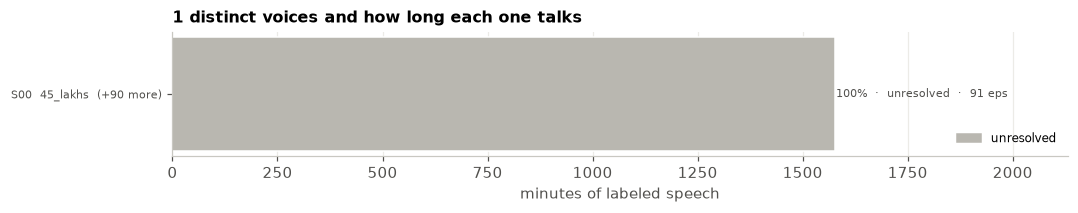

The largest voice (S00, 45_lakhs...) holds 100% of the speech; the top 5 hold 100%. Median speaker: 1578 min.
100% of gold speech comes from a speaker who also talks in train - gold is not speaker-held-out.


In [7]:
fig, ax = plt.subplots(figsize=(10.5, 0.27 * len(SPK) + 1.2))
order = SPK.iloc[::-1]
ax.barh(range(len(order)), order.talk_min, color=[GENDER_COLOR[g] for g in order.gender],
        height=0.72, edgecolor="white", linewidth=1)
for y, (sp, r) in enumerate(order.iterrows()):
    ax.text(r.talk_min + 1.5, y, f"{r['share %']:.0f}%  ·  {r.age.replace('_', '-')}  ·  "
            f"{r.episodes} ep{'s' if r.episodes > 1 else ''}", va="center", fontsize=7.5, color=MUTED)
ax.set_yticks(range(len(order)), [f"{sp}  {r.first_episode[:28]}" for sp, r in order.iterrows()], fontsize=7.5)
script_aware(ax.get_yticklabels())
ax.set_xlabel("minutes of labeled speech")
ax.set_xlim(0, order.talk_min.max() * 1.35)
ax.grid(axis="y", visible=False)
ax.set_title(f"{len(SPK)} distinct voices and how long each one talks")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c, label=g) for g, c in GENDER_COLOR.items()
                   if g in set(SPK.gender)],
          loc="lower right", fontsize=8)
save(fig, "01_speakers")
plt.show()

top = SPK.iloc[0]
print(f"The largest voice ({top.name}, {top.first_episode.split('  ')[0]}...) holds {top['share %']:.0f}% of the "
      f"speech; the top 5 hold {SPK['share %'].head(5).sum():.0f}%. Median speaker: {SPK.talk_min.median():.0f} min.")
gold_heard = SPK.gold_min[SPK.talk_min - SPK.gold_min > 0].sum() / SPK.gold_min.sum()
print(f"{gold_heard:.0%} of gold speech comes from a speaker who also talks in train - gold is not "
      "speaker-held-out.")

## 2. What the corpus holds

Gender and age below are **per second of speech**, from the voice attribution above — not the
per-episode "mixed" label, which says nothing about who holds the microphone.

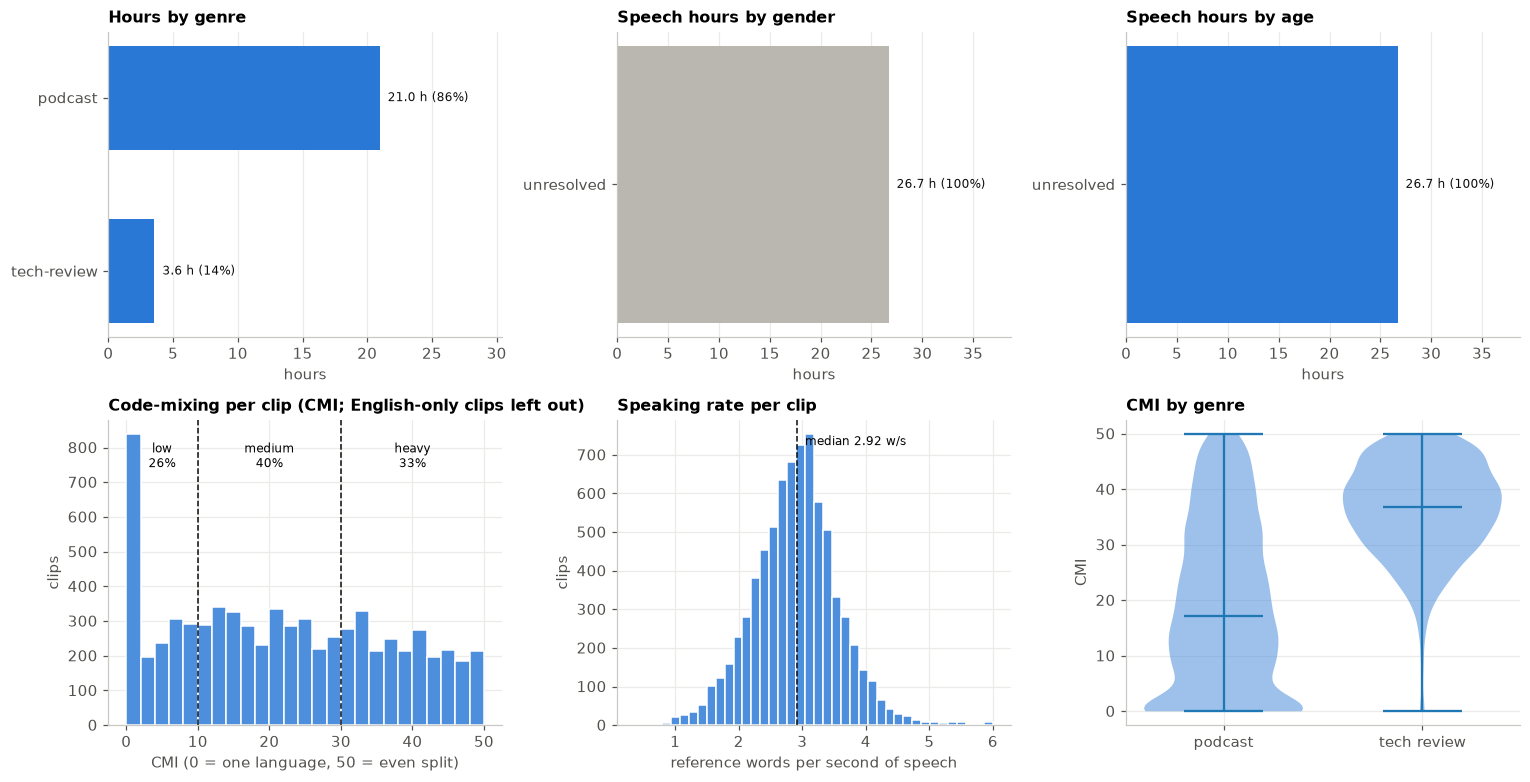

In [17]:
hours = lambda col: seg.groupby(col).duration.sum().div(3600)  # noqa: E731

fig, axes = plt.subplots(2, 3, figsize=(14, 7.2))
panels = [
    (axes[0, 0], hours("genre").sort_values(), "Hours by genre", None),
    (axes[0, 1], hours("gender").reindex(["unresolved", "male", "female"]).dropna(), "Speech hours by gender",
     GENDER_COLOR),
    (axes[0, 2], hours("age").reindex(["unresolved", "60_79", "40_59", "20_39"]).dropna(), "Speech hours by age", None),
]
for ax, series_, title, colors in panels:
    cols = [colors.get(i, "#2a78d6") for i in series_.index] if colors else "#2a78d6"
    ax.barh([str(i).replace("_", "-") for i in series_.index], series_.values, color=cols, height=0.6)
    for y, v in enumerate(series_.values):
        ax.text(v, y, f"  {v:.1f} h ({100 * v / series_.sum():.0f}%)", va="center", fontsize=8, color=INK)
    ax.set_xlim(0, series_.max() * 1.45)
    ax.grid(axis="y", visible=False)
    ax.set_title(title)
    ax.set_xlabel("hours")

ax = axes[1, 0]
mixed = scored[scored.cmi_tier != "English only"]
bins = np.arange(0, 52, 2)
ax.hist(mixed.cmi, bins=bins, color="#4d8fdc", edgecolor="white")
for x in (10, 30):
    ax.axvline(x, color=INK, lw=1, ls="--")
for x0, x1, name in ((0, 10, "low"), (10, 30, "medium"), (30, 50, "heavy")):
    share = ((mixed.cmi >= x0) & (mixed.cmi < x1 if x1 < 50 else mixed.cmi <= 50)).mean()
    ax.text((x0 + x1) / 2, ax.get_ylim()[1] * 0.93, f"{name}\n{share:.0%}", ha="center", va="top", fontsize=8)
ax.set(title="Code-mixing per clip (CMI; English-only clips left out)", xlabel="CMI (0 = one language, 50 = even split)", ylabel="clips")

ax = axes[1, 1]
ax.hist(scored.rate.clip(upper=6), bins=40, color="#4d8fdc", edgecolor="white")
ax.axvline(scored.rate.median(), color=INK, lw=1, ls="--")
ax.text(scored.rate.median(), ax.get_ylim()[1] * 0.95, f"  median {scored.rate.median():.2f} w/s", fontsize=8, va="top")
ax.set(title="Speaking rate per clip", xlabel="reference words per second of speech", ylabel="clips")

ax = axes[1, 2]
by_genre = [scored.cmi[scored.genre == g].to_numpy() for g in ("podcast", "tech_review", "shorts_reels")]
parts_ = ax.violinplot(by_genre, showmedians=True, widths=0.8)
for body in parts_["bodies"]:
    body.set_facecolor("#4d8fdc")
    body.set_alpha(0.55)
ax.set_xticks([1, 2], ["podcast", "tech review"])
ax.set(title="CMI by genre", ylabel="CMI")
fig.tight_layout()
save(fig, "02_distribution")
plt.show()

In [9]:
summary = pd.DataFrame({
    "clips": scored.groupby("cmi_tier").size(),
    "hours": scored.groupby("cmi_tier").duration.sum() / 3600,
    "Latin tokens %": 100 * scored.groupby("cmi_tier").n_lat.sum() / (scored.groupby("cmi_tier").n_dev.sum() + scored.groupby("cmi_tier").n_lat.sum()),
    "tech review %": 100 * scored.groupby("cmi_tier").genre.apply(lambda s: (s == "tech_review").mean()),
    "median words/s": scored.groupby("cmi_tier").rate.median(),
}).reindex(TIERS)
summary["share %"] = 100 * summary.clips / summary.clips.sum()
display(summary)
lat = scored.n_lat.sum() / (scored.n_lat.sum() + scored.n_dev.sum())
print(f"{lat:.1%} of reference words are English (Latin script); mean CMI {scored.cmi.mean():.1f}, "
      f"median {scored.cmi.median():.1f}.")
print(f"By talk time: female {hours('gender').get('female', 0) / (seg.duration.sum() / 3600):.0%}, "
      f"male {hours('gender').get('male', 0) / (seg.duration.sum() / 3600):.0%}.")

,clips,hours,Latin tokens %,tech review %,median words/s,share %
cmi_tier,,,,,,
Low (<10),1869,5.80,10.74,0.21,2.77,24.74
Medium (10-30),2871,10.47,25.98,5.02,2.97,38.00
Heavy (>=30),2369,9.53,43.33,22.71,3.00,31.36
English only,446,0.85,100.00,0.67,2.60,5.90


31.2% of reference words are English (Latin script); mean CMI 20.6, median 19.6.
By talk time: female 0%, male 0%.


## 3. Recognition as code-mixing increases

Tiers by the reference's CMI: **Low** (< 10: essentially one language, with an English word or
two), **Medium** (10–30) and **Heavy** (≥ 30: approaching an even split). Clips with no Devanagari
at all are pulled out as **English only**: CMI scores them 0, the same as pure Nepali, but they
are a different recognition problem and would hide inside "Low" otherwise.

Intervals are 95% bootstraps that resample **speakers**, not clips: clips from one voice share a
microphone, a room and a way of talking, and 27 voices are far fewer independent draws than
6,500 clips.

WER %  raw WER %  CER %  WER lo  WER hi  clips
CMI tier       system                                                
Low (<10)      Scribe  12.62      18.42   8.74    3.55   12.70   1869
               Gemini  11.06      19.05   8.94    4.08   11.11   1869
               MAI     12.47      20.49  11.02    3.60   12.55   1869
Medium (10-30) Scribe  11.46      20.73  10.69    5.16   11.53   2871
               Gemini  10.24      21.91  11.34    5.34   10.28   2871
               MAI     11.36      19.61  10.49    3.68   11.44   2871
Heavy (>=30)   Scribe   7.84      18.68   9.87    3.61    7.88   2369
               Gemini   7.46      19.97  10.79    2.04    7.51   2369
               MAI      6.63      13.10   6.35    2.50    6.67   2369
English only   Scribe   2.51       3.42   2.08    2.51    2.51    446
               Gemini   6.11       9.80   5.06    6.11    6.11    446
               MAI     22.37      86.81  71.45   22.37   22.37    446

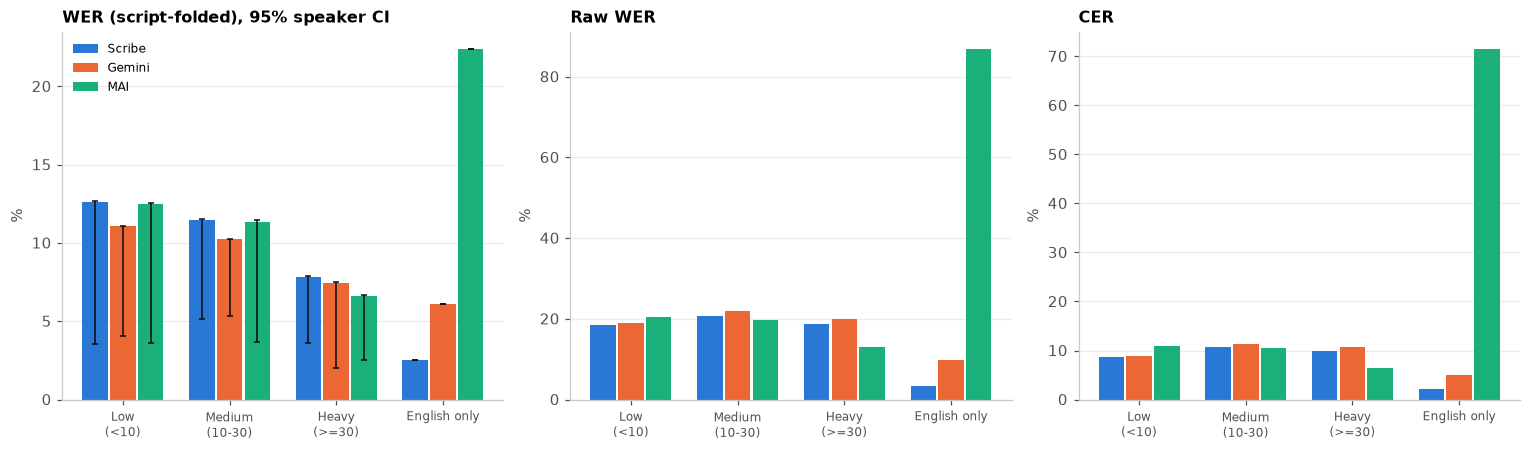

  Scribe  WER low -> medium -> heavy: 12.6 -> 11.5 -> 7.8 %   English only 2.5 %
  Gemini  WER low -> medium -> heavy: 11.1 -> 10.2 -> 7.5 %   English only 6.1 %
  MAI     WER low -> medium -> heavy: 12.5 -> 11.4 -> 6.6 %   English only 22.4 %


In [10]:
scored["cluster"] = scored.speaker.fillna("ep:" + scored.episode)
by_tier = pd.concat({t: wer_table(scored[scored.cmi_tier == t], cluster="cluster") for t in TIERS})
by_tier.index.names = ["CMI tier", "system"]
by_tier = by_tier.join(scored.groupby("cmi_tier").size().rename("clips"), on="CMI tier")
display(by_tier)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=False)
x = np.arange(len(TIERS))
wd = 0.26
for ax, metric in zip(axes, ["WER %", "raw WER %", "CER %"]):
    for k, s in enumerate(SYSTEMS):
        vals = by_tier.xs(SHORT[s], level="system").reindex(TIERS)
        err = None
        if metric == "WER %":
            err = np.vstack([vals[metric] - vals["WER lo"], vals["WER hi"] - vals[metric]])
        ax.bar(x + (k - 1) * wd, vals[metric], wd * 0.92, color=SYS_COLOR[s], label=SHORT[s],
               yerr=err, error_kw={"elinewidth": 1, "capsize": 2, "ecolor": INK})
    ax.set_xticks(x, [t.replace(" (", "\n(") for t in TIERS], fontsize=8)
    ax.set_title({"WER %": "WER (script-folded), 95% speaker CI", "raw WER %": "Raw WER",
                  "CER %": "CER"}[metric])
    ax.set_ylabel("%")
    ax.grid(axis="x", visible=False)
axes[0].legend(fontsize=8, loc="upper left")
fig.tight_layout()
save(fig, "03_wer_by_cmi")
plt.show()

w = by_tier["WER %"].unstack("system").reindex(TIERS)
for s in SHORT.values():
    print(f"  {s:<7} WER low -> medium -> heavy: {w.loc[TIERS[0], s]:.1f} -> {w.loc[TIERS[1], s]:.1f} -> "
          f"{w.loc[TIERS[2], s]:.1f} %   English only {w.loc[TIERS[3], s]:.1f} %")

**Heavy mixing and the tech reviews are nearly the same clips**, so a tier difference could be
the reviewer rather than the mixing. The same table restricted to podcasts separates the two.

In [11]:
pod = scored[scored.genre == "podcast"]
pod_tier = pd.concat({t: wer_table(pod[pod.cmi_tier == t], cluster="cluster") for t in TIERS
                      if (pod.cmi_tier == t).sum() >= 50})
print("podcasts only - WER % by CMI tier (speaker CI):")
display(pod_tier["WER %"].unstack().round(1).join(pod.groupby("cmi_tier").size().rename("clips")))

podcasts only - WER % by CMI tier (speaker CI):


,Scribe,Gemini,MAI,clips
Low (<10),13.30,11.60,13.20,1696
Medium (10-30),12.60,11.30,12.80,2495
Heavy (>=30),9.40,9.40,8.90,1730
English only,2.40,6.20,22.70,440


## 4. Recognition as speech gets faster

Speaking rate is reference words per second of speech (Scribe's first-to-last word span, so
leading and trailing silence does not count). A Nepali word carries more syllables than most
English ones, so rate is partly a proxy for language mix; the second panel therefore repeats the
curve within each CMI tier.

system,words/s,Scribe,Gemini,MAI,clips,heavy-CMI %
rate quintile,,,,,,
0,0.37-2.37,8.30,7.90,10.30,1511,25.61
1,2.37-2.76,9.50,8.40,9.40,1513,26.90
2,2.76-3.06,8.90,8.70,8.60,1509,34.99
3,3.06-3.40,9.60,8.70,9.20,1511,40.64
4,3.40-15.47,13.00,11.60,13.20,1511,28.66


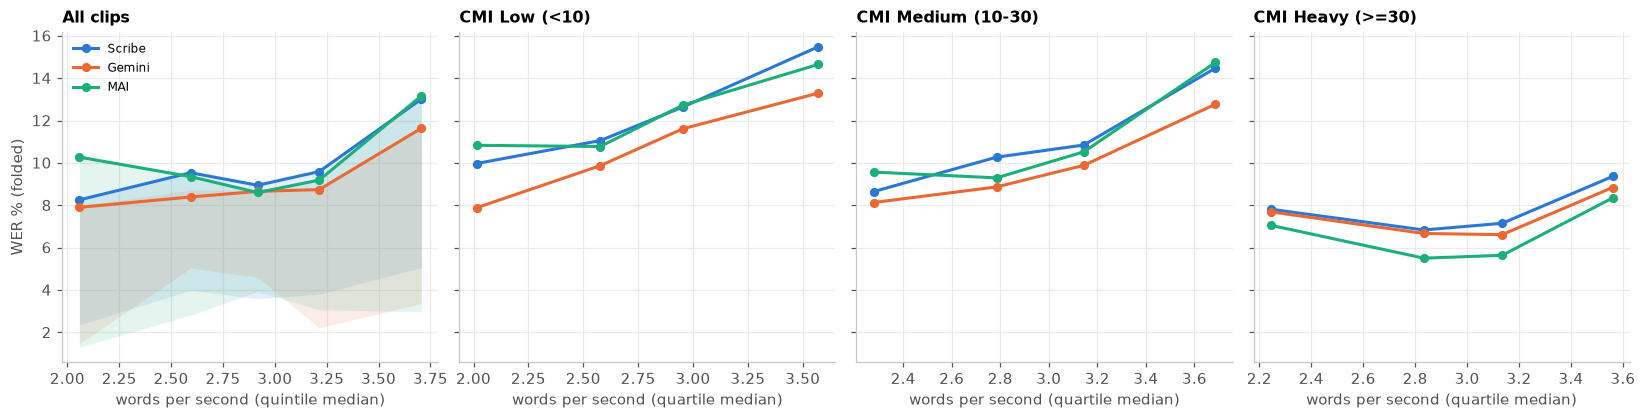

Spearman rank correlation, speaking rate vs per-clip WER (positive = faster is worse):


,all clips,within Low (<10),within Medium (10-30),within Heavy (>=30)
Scribe,0.20,0.22,0.24,0.14
Gemini,0.18,0.19,0.23,0.11
MAI,0.12,0.18,0.20,0.11


In [12]:
QN = 5
scored["rate_bin"] = pd.qcut(scored.rate, QN, labels=False)
edges = scored.groupby("rate_bin").rate.agg(["min", "max", "median"])
by_rate = pd.concat({b: wer_table(scored[scored.rate_bin == b], cluster="cluster") for b in range(QN)})
by_rate.index.names = ["rate quintile", "system"]
table = by_rate["WER %"].unstack().round(1)
table.insert(0, "words/s", [f"{edges.loc[b, 'min']:.2f}-{edges.loc[b, 'max']:.2f}" for b in range(QN)])
table["clips"] = scored.groupby("rate_bin").size()
table["heavy-CMI %"] = 100 * scored.groupby("rate_bin").cmi_tier.apply(lambda s: (s == TIERS[2]).mean())
display(table)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.9), sharey=True)
ax = axes[0]
for s in SYSTEMS:
    v = by_rate.xs(SHORT[s], level="system")
    ax.plot(edges["median"], v["WER %"], marker="o", ms=5, lw=2, color=SYS_COLOR[s], label=SHORT[s])
    ax.fill_between(edges["median"], v["WER lo"], v["WER hi"], color=SYS_COLOR[s], alpha=0.12, lw=0)
ax.set(title="All clips", xlabel="words per second (quintile median)", ylabel="WER % (folded)")
ax.legend(fontsize=8)
for ax, t in zip(axes[1:], TIERS[:3]):
    sub = scored[scored.cmi_tier == t].copy()
    sub["b"] = pd.qcut(sub.rate, 4, labels=False)
    mids = sub.groupby("b").rate.median()
    for s in SYSTEMS:
        wv = sub.groupby("b")[f"{s}|werr"].sum() / sub.groupby("b").words.sum() * 100
        ax.plot(mids, wv, marker="o", ms=5, lw=2, color=SYS_COLOR[s])
    ax.set(title=f"CMI {t}", xlabel="words per second (quartile median)")
fig.tight_layout()
save(fig, "04_wer_by_rate")
plt.show()

rho = {}
for s in SYSTEMS:
    seg_wer = scored[f"{s}|werr"] / scored.words
    rho[SHORT[s]] = {"all clips": spearmanr(scored.rate, seg_wer).statistic,
                     **{f"within {t}": spearmanr(scored.rate[scored.cmi_tier == t], seg_wer[scored.cmi_tier == t]).statistic
                        for t in TIERS[:3]}}
print("Spearman rank correlation, speaking rate vs per-clip WER (positive = faster is worse):")
display(pd.DataFrame(rho).T.round(3))

## 5. Recognition as voices overlap

Overlap is the share of a clip where two or more people talk at once, measured over the whole
episode by pyannote's segmentation model at ingest or by `scripts/backfill_overlap.py` (D77).
A fine-tuned model's errors rise steeply with it: within an episode, each 10 points of overlap
share multiplied Flex's error rate by about 1.5, while speaking rate and code-mixing showed no
effect (docs/findings.md). Overlap is never used to drop a clip, only to read results.

**Caveat.** These references are the fusion of the same three recognisers. In overlap each
recogniser follows one voice and the fuser arbitrates, so the reference is at its least
reliable exactly where this section looks.

7,555 of 7,555 clips measured; 26% have some overlap, 17% at least 0.5 s


,Scribe,Gemini,MAI,clips
overlap share,,,,
none,8.50,7.50,8.30,5623
0-5%,10.90,10.00,11.50,919
5-15%,13.60,13.60,13.90,691
>15%,18.20,18.20,18.70,322


podcasts only - WER % by overlap share (speaker CI), so genre cannot carry the effect:


,Scribe,Gemini,MAI,clips
none,10.00,8.80,10.60,4503
0-5%,11.20,10.20,12.00,869
5-15%,13.60,13.70,14.00,670
>15%,18.20,18.20,18.70,319


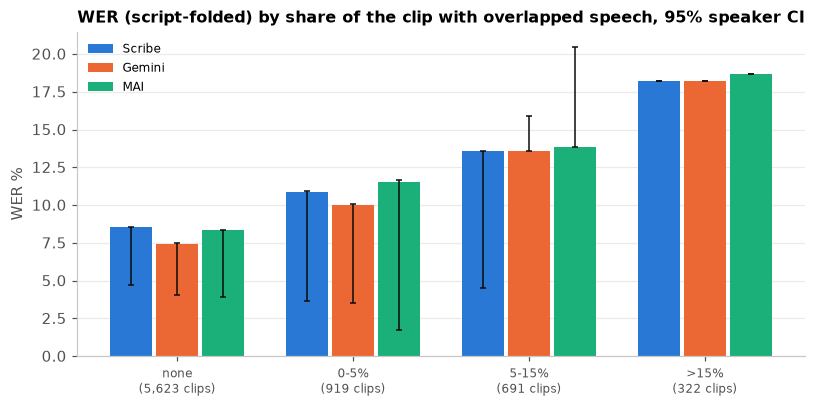

In [13]:
OV_TIERS = ["none", "0-5%", "5-15%", ">15%"]
OV_COLOR = dict(zip(OV_TIERS, ["#9cc3ee", "#4d8fdc", "#1d5aa6", "#0d366b"]))  # one hue, light->dark
measured = scored[scored.overlap_s.notna()].copy()
by_ov = None
if measured.empty:
    print("this export carries no overlap spans: run scripts/backfill_overlap.py, re-export, rerun (D77)")
else:
    measured["ov_tier"] = pd.cut(measured.overlap_s / measured.duration, [-1e-9, 0, 0.05, 0.15, 1],
                                 labels=OV_TIERS)
    present = [t for t in OV_TIERS if (measured.ov_tier == t).any()]
    by_ov = pd.concat({t: wer_table(measured[measured.ov_tier == t], cluster="cluster") for t in present})
    by_ov.index.names = ["overlap share", "system"]
    clips = measured.groupby("ov_tier", observed=True).size().rename("clips")
    print(f"{len(measured):,} of {len(scored):,} clips measured; {(measured.overlap_s > 0).mean():.0%} "
          f"have some overlap, {(measured.overlap_s >= 0.5).mean():.0%} at least 0.5 s")
    display(by_ov["WER %"].unstack().reindex(present).round(1).join(clips))

    pod_m = measured[measured.genre == "podcast"]
    pod_present = [t for t in OV_TIERS if (pod_m.ov_tier == t).sum() >= 20]
    pod_ov = pd.concat({t: wer_table(pod_m[pod_m.ov_tier == t], cluster="cluster") for t in pod_present})
    print("podcasts only - WER % by overlap share (speaker CI), so genre cannot carry the effect:")
    display(pod_ov["WER %"].unstack().reindex(pod_present).round(1)
            .join(pod_m.groupby("ov_tier", observed=True).size().rename("clips")))

    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    x = np.arange(len(present))
    wd = 0.26
    for k, s in enumerate(SYSTEMS):
        vals = by_ov.xs(SHORT[s], level="system").reindex(present)
        err = np.vstack([vals["WER %"] - vals["WER lo"], vals["WER hi"] - vals["WER %"]])
        ax.bar(x + (k - 1) * wd, vals["WER %"], wd * 0.92, color=SYS_COLOR[s], label=SHORT[s],
               yerr=err, error_kw={"elinewidth": 1, "capsize": 2, "ecolor": INK})
    ax.set_xticks(x, [f"{t}\n({clips[t]:,} clips)" for t in present], fontsize=8)
    ax.set(title="WER (script-folded) by share of the clip with overlapped speech, 95% speaker CI",
           ylabel="WER %")
    ax.grid(axis="x", visible=False)
    ax.legend(fontsize=8, loc="upper left")
    fig.tight_layout()
    save(fig, "05_wer_by_overlap")
    plt.show()

## 6. Per speaker

The same WER for every voice with at least 10 minutes of speech: the spread between people is
the variation a speaker-held-out test set would have to sample.

In [14]:
big = SPK[SPK.talk_min >= 10].index
per_spk = pd.concat({sp: wer_table(scored[scored.speaker == sp])["WER %"] for sp in big}).unstack().round(1)
per_spk = SPK.loc[big, ["talk_min", "gender", "age", "first_episode"]].join(per_spk)
per_spk["CMI"] = scored.groupby("speaker").cmi.mean().reindex(big).round(1)
per_spk["words/s"] = scored.groupby("speaker").rate.median().reindex(big).round(2)
display(per_spk)
best = per_spk[list(SHORT.values())]
print(f"per-speaker WER spans {best.min(axis=1).min():.1f}-{best.max(axis=1).max():.1f}%; "
      f"the best recogniser differs by speaker: {best.idxmin(axis=1).value_counts().to_dict()}")

,talk_min,gender,age,first_episode,Scribe,Gemini,MAI,CMI,words/s
speaker,,,,,,,,,
S00,"1,578.18",unresolved,unresolved,45_lakhs (+90 more),10.20,9.30,10.20,20.50,2.92


per-speaker WER spans 9.3-10.2%; the best recogniser differs by speaker: {'Gemini': 1}


## 7. What it says

Printed from the frames above, so a rerun on a newer export rewrites it.

In [15]:
tot_h = seg.duration.sum() / 3600
lines = [
    f"CORPUS  {len(seg):,} clips, {tot_h:.2f} h, {seg.episode.nunique()} episodes, {len(SPK)} distinct voices "
    f"(metadata implies {expected}).",
    f"        largest voice {SPK['share %'].iloc[0]:.0f}% of speech; top 5 {SPK['share %'].head(5).sum():.0f}%; "
    f"female {hours('gender').get('female', 0) / tot_h:.0%} / male {hours('gender').get('male', 0) / tot_h:.0%} "
    f"/ unresolved {hours('gender').get('unresolved', 0) / tot_h:.0%} of talk time.",
    "        ages: " + ", ".join(f"{k.replace('_', '-')} {v / tot_h:.0%}" for k, v in hours('age').items()) + ".",
    f"MIXING  {lat:.0%} of words are English; " + ", ".join(
        f"{t.split(' (')[0].lower()} {summary.loc[t, 'share %']:.0f}%" for t in TIERS) + " of clips.",
    "WER     (folded; low / medium / heavy CMI / English-only)",
]
for s in SHORT.values():
    lines.append(f"        {s:<7} " + " / ".join(f"{w.loc[t, s]:.1f}" for t in TIERS))
lines += [
    "CER     (low / medium / heavy CMI): " + "; ".join(
        f"{s} " + " / ".join(f"{by_tier.loc[(t, s), 'CER %']:.1f}" for t in TIERS[:3]) for s in SHORT.values()),
    "SPEED   quintile WER, slowest -> fastest: " + "; ".join(
        f"{s} {table[s].iloc[0]:.1f} -> {table[s].iloc[-1]:.1f}" for s in SHORT.values()),
    "        Spearman(rate, clip WER) within CMI tiers: "
    + f"{pd.DataFrame(rho).T.iloc[:, 1:].min().min():.2f} to {pd.DataFrame(rho).T.iloc[:, 1:].max().max():.2f} "
    + f"(all clips pooled: {pd.DataFrame(rho).T.iloc[:, 0].min():.2f} to {pd.DataFrame(rho).T.iloc[:, 0].max():.2f}).",
    ("OVERLAP not measured in this export (D77)." if by_ov is None else
     "OVERLAP WER none -> most overlapped: " + "; ".join(
         f"{s} {by_ov.xs(s, level='system')['WER %'].iloc[0]:.1f} -> {by_ov.xs(s, level='system')['WER %'].iloc[-1]:.1f}"
         for s in SHORT.values())),
    f"GOLD    {gold_heard:.0%} of gold speech is from voices that also train; not speaker-held-out.",
    "CAVEAT  references are the fused transcript of these three recognisers, barely edited.",
]
print("\n".join(lines))

CORPUS  7,581 clips, 26.69 h, 126 episodes, 1 distinct voices (metadata implies 33).
        largest voice 100% of speech; top 5 100%; female 0% / male 0% / unresolved 100% of talk time.
        ages: unresolved 100%.
MIXING  31% of words are English; low 25%, medium 38%, heavy 31%, english only 6% of clips.
WER     (folded; low / medium / heavy CMI / English-only)
        Scribe  12.6 / 11.5 / 7.8 / 2.5
        Gemini  11.1 / 10.2 / 7.5 / 6.1
        MAI     12.5 / 11.4 / 6.6 / 22.4
CER     (low / medium / heavy CMI): Scribe 8.7 / 10.7 / 9.9; Gemini 8.9 / 11.3 / 10.8; MAI 11.0 / 10.5 / 6.4
SPEED   quintile WER, slowest -> fastest: Scribe 8.3 -> 13.0; Gemini 7.9 -> 11.6; MAI 10.3 -> 13.2
        Spearman(rate, clip WER) within CMI tiers: 0.11 to 0.25 (all clips pooled: 0.12 to 0.20).
OVERLAP WER none -> most overlapped: Scribe 8.5 -> 18.2; Gemini 7.5 -> 18.2; MAI 8.3 -> 18.7
GOLD    100% of gold speech is from voices that also train; not speaker-held-out.
CAVEAT  references are the fus